In [60]:
#Read the dataset
import pandas as pd
df=pd.read_csv("/content/Maternal Health Risk Data Set.csv")
df

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk


In [61]:
#Check the null values
df.isnull().sum()

,0
Age,0
SystolicBP,0
DiastolicBP,0
BS,0
BodyTemp,0
HeartRate,0
RiskLevel,0


In [62]:
#Find the Target and Features
y=df['RiskLevel']
print(y)
x=df.drop('RiskLevel',axis=1)
x

0       high risk
1       high risk
2       high risk
3       high risk
4        low risk
          ...    
1009    high risk
1010    high risk
1011    high risk
1012    high risk
1013     mid risk
Name: RiskLevel, Length: 1014, dtype: object


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
0,25,130,80,15.0,98.0,86
1,35,140,90,13.0,98.0,70
2,29,90,70,8.0,100.0,80
3,30,140,85,7.0,98.0,70
4,35,120,60,6.1,98.0,76
...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80
1010,55,120,90,18.0,98.0,60
1011,35,85,60,19.0,98.0,86
1012,43,120,90,18.0,98.0,70


In [63]:
#Converting strings to numbers(Mapping)
from sklearn.preprocessing import LabelEncoder
l=LabelEncoder()
y = pd.DataFrame(l.fit_transform(df['RiskLevel']), columns=['RiskLevel_Encoded'])
y

,RiskLevel_Encoded
0,0
1,0
2,0
3,0
4,1
...,...
1009,0
1010,0
1011,0
1012,0


In [64]:
x.columns

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate'], dtype='object')

In [65]:
#Normalize the data
from sklearn.preprocessing import MinMaxScaler
m=MinMaxScaler()
col=['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
for i in col:
  x[i]=m.fit_transform(x[[i]])
x

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
0,0.250000,0.666667,0.607843,0.692308,0.0,0.951807
1,0.416667,0.777778,0.803922,0.538462,0.0,0.759036
2,0.316667,0.222222,0.411765,0.153846,0.4,0.879518
3,0.333333,0.777778,0.705882,0.076923,0.0,0.759036
4,0.416667,0.555556,0.215686,0.007692,0.0,0.831325
...,...,...,...,...,...,...
1009,0.200000,0.555556,0.215686,0.692308,0.0,0.879518
1010,0.750000,0.555556,0.803922,0.923077,0.0,0.638554
1011,0.416667,0.166667,0.215686,1.000000,0.0,0.951807
1012,0.550000,0.555556,0.803922,0.923077,0.0,0.759036


In [66]:
#Before SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LogisticRegression(max_iter=500)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
acc=accuracy_score(y_test,y_pred)
print("BEFORE SMOTE\n")
print("Accurancy:",acc)
print("Classification report:",classification_report(y_test,y_pred))
print("Confusion matrix:\n",confusion_matrix(y_test,y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


BEFORE SMOTE

Accurancy: 0.6305418719211823
Classification report:               precision    recall  f1-score   support

           0       0.69      0.81      0.75        47
           1       0.60      0.88      0.71        80
           2       0.62      0.26      0.37        76

    accuracy                           0.63       203
   macro avg       0.64      0.65      0.61       203
weighted avg       0.63      0.63      0.59       203

Confusion matrix:
 [[38  3  6]
 [ 4 70  6]
 [13 43 20]]


In [67]:
#After SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
from imblearn.over_sampling import SMOTE
s=SMOTE()
x_u,y_u=s.fit_resample(x,y)
accurancy=[]
x_train,x_test,y_train,y_test=train_test_split(x_u,y_u,test_size=0.2,random_state=42)
model=LogisticRegression(max_iter=500)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
acc=accuracy_score(y_test,y_pred)
accurancy.append(acc)
print("AFTER SMOTE\n")
print("Accurancy:",acc)
print("Classification report:\n",classification_report(y_test,y_pred))
print("Confusion matrix:\n",confusion_matrix(y_test,y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


AFTER SMOTE

Accurancy: 0.6475409836065574
Classification report:
               precision    recall  f1-score   support

           0       0.77      0.82      0.79        73
           1       0.65      0.71      0.68        87
           2       0.51      0.43      0.47        84

    accuracy                           0.65       244
   macro avg       0.64      0.65      0.65       244
weighted avg       0.64      0.65      0.64       244

Confusion matrix:
 [[60  1 12]
 [ 3 62 22]
 [15 33 36]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


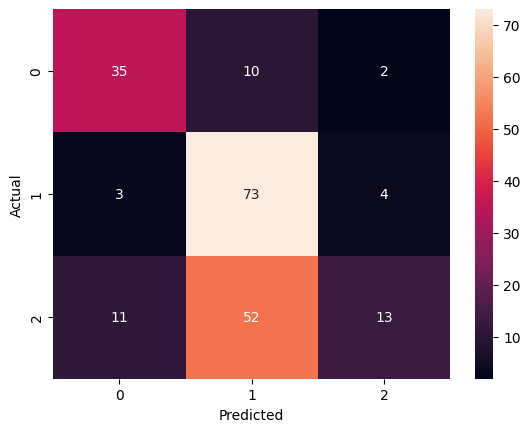

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


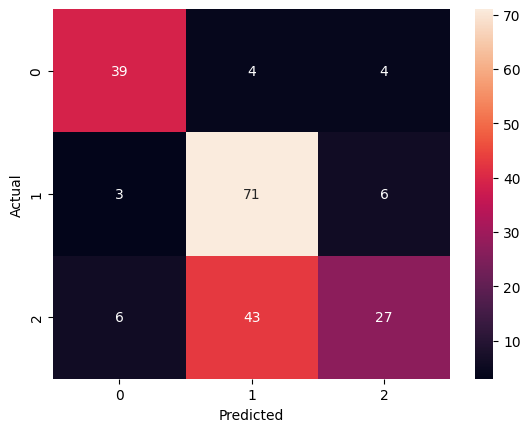

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


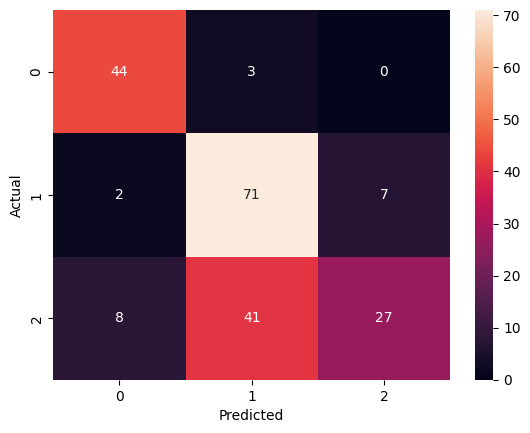

BEFORE SMOTE

CLASSIFICATION REPORT: 
               precision    recall  f1-score   support

           0       0.71      0.74      0.73        47
           1       0.54      0.91      0.68        80
           2       0.68      0.17      0.27        76

    accuracy                           0.60       203
   macro avg       0.65      0.61      0.56       203
weighted avg       0.63      0.60      0.54       203

Accuracy of linear kernel: [0.5960591133004927]
CLASSIFICATION REPORT: 
               precision    recall  f1-score   support

           0       0.81      0.83      0.82        47
           1       0.60      0.89      0.72        80
           2       0.73      0.36      0.48        76

    accuracy                           0.67       203
   macro avg       0.71      0.69      0.67       203
weighted avg       0.70      0.67      0.65       203

Accuracy of poly kernel: [0.6748768472906403]
CLASSIFICATION REPORT: 
               precision    recall  f1-score   support



In [68]:
#Before SMOTE using SVM
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
ac1=[]
ac2=[]
ac3=[]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
svm_linear=SVC(kernel="linear")
svm_linear.fit(x_train,y_train)
y_pred1=svm_linear.predict(x_test)
accuracy=accuracy_score(y_test,y_pred1)
ac1.append(accuracy)
cm = confusion_matrix(y_test, y_pred1)
sns.heatmap(cm,annot=True,fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
svm_poly=SVC(kernel="poly")
svm_poly.fit(x_train,y_train)
y_pred2=svm_poly.predict(x_test)
accuracy1=accuracy_score(y_test,y_pred2)
ac2.append(accuracy1)
cm = confusion_matrix(y_test, y_pred2)
sns.heatmap(cm,annot=True,fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
svm_rbf=SVC(kernel="rbf")
svm_rbf.fit(x_train,y_train)
y_pred3=svm_rbf.predict(x_test)
accuracy3=accuracy_score(y_test,y_pred3)
ac3.append(accuracy3)
cm = confusion_matrix(y_test, y_pred3)
sns.heatmap(cm,annot=True,fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("BEFORE SMOTE\n")
print("CLASSIFICATION REPORT: \n",classification_report(y_test,y_pred1))
print("Accuracy of linear kernel:",ac1)
print("CLASSIFICATION REPORT: \n",classification_report(y_test,y_pred2))
print("Accuracy of poly kernel:",ac2)
print("CLASSIFICATION REPORT: \n",classification_report(y_test,y_pred3))
print("Accuracy of rbf kernel:",ac3)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


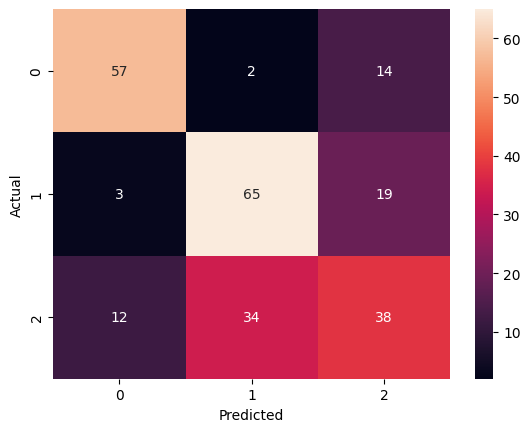

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


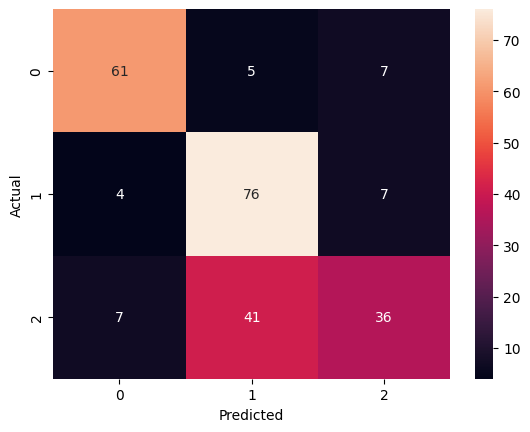

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


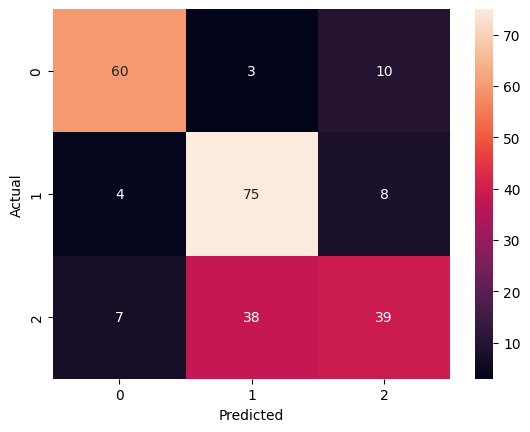

AFTER SMOTE

CLASSIFICATION REPORT: 
               precision    recall  f1-score   support

           0       0.79      0.78      0.79        73
           1       0.64      0.75      0.69        87
           2       0.54      0.45      0.49        84

    accuracy                           0.66       244
   macro avg       0.66      0.66      0.66       244
weighted avg       0.65      0.66      0.65       244

Accuracy of linear kernel: [0.6557377049180327]
CLASSIFICATION REPORT: 
               precision    recall  f1-score   support

           0       0.85      0.84      0.84        73
           1       0.62      0.87      0.73        87
           2       0.72      0.43      0.54        84

    accuracy                           0.71       244
   macro avg       0.73      0.71      0.70       244
weighted avg       0.72      0.71      0.70       244

Accuracy of poly kernel: [0.7090163934426229]
CLASSIFICATION REPORT: 
               precision    recall  f1-score   support

 

In [69]:
#After SMOTE using SVM
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
s=SMOTE()
x_u,y_u=s.fit_resample(x,y)
ac1=[]
ac2=[]
ac3=[]
x_train,x_test,y_train,y_test=train_test_split(x_u,y_u,test_size=0.2,random_state=42)
svm_linear=SVC(kernel="linear")
svm_linear.fit(x_train,y_train)
y_pred1=svm_linear.predict(x_test)
accuracy=accuracy_score(y_test,y_pred1)
ac1.append(accuracy)
cm = confusion_matrix(y_test, y_pred1)
sns.heatmap(cm,annot=True,fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
svm_poly=SVC(kernel="poly")
svm_poly.fit(x_train,y_train)
y_pred2=svm_poly.predict(x_test)
accuracy1=accuracy_score(y_test,y_pred2)
ac2.append(accuracy1)
cm = confusion_matrix(y_test, y_pred2)
sns.heatmap(cm,annot=True,fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
svm_rbf=SVC(kernel="rbf")
svm_rbf.fit(x_train,y_train)
y_pred3=svm_rbf.predict(x_test)
accuracy3=accuracy_score(y_test,y_pred3)
ac3.append(accuracy3)
cm = confusion_matrix(y_test, y_pred3)
sns.heatmap(cm,annot=True,fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("AFTER SMOTE\n")
print("CLASSIFICATION REPORT: \n",classification_report(y_test,y_pred1))
print("Accuracy of linear kernel:",ac1)
print("CLASSIFICATION REPORT: \n",classification_report(y_test,y_pred2))
print("Accuracy of poly kernel:",ac2)
print("CLASSIFICATION REPORT: \n",classification_report(y_test,y_pred3))
print("Accuracy of rbf kernel:",ac3)

In [70]:
#KFOLD FOR LINEAR AFTER SMOTE
from sklearn.model_selection import KFold
import numpy as np
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=1)
x_u,y_u=sm.fit_resample(x,y)
kfold=KFold(n_splits=5,shuffle=True,random_state=42)
accuracies=[]
for train_index,test_index in kfold.split(x):
  x_train,x_test=x.iloc[train_index],x.iloc[test_index]
  y_train,y_test=y.iloc[train_index],y.iloc[test_index]
  model=SVC(kernel="linear")
  model.fit(x_train,y_train)
  y_pred1=model.predict(x_test)
  accuracy=accuracy_score(y_test,y_pred1)
  accuracies.append(accuracy)
print("LINEAR: \n")
print("Accuracies:",accuracies)
mean_acc1=np.mean(accuracies)
print(f"Mean Accuracy : ",mean_acc1)
sum=0
for i in accuracies:
  sum+=(i-mean_acc1)**2
standard_error=np.sqrt(sum/len(accuracies))
print(f"Standard Error : {standard_error}")

LINEAR: 

Accuracies: [0.5960591133004927, 0.6157635467980296, 0.6551724137931034, 0.6798029556650246, 0.6336633663366337]
Mean Accuracy :  0.6360922791786568
Standard Error : 0.029313771930023682


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

In [71]:
#K-Fold for poly after SMOTE
from sklearn.model_selection import KFold
import numpy as np
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=1)
x_u,y_u=sm.fit_resample(x,y)
kfold=KFold(n_splits=5,shuffle=True,random_state=42)
accuracies=[]
for train_index,test_index in kfold.split(x):
  x_train,x_test=x.iloc[train_index],x.iloc[test_index]
  y_train,y_test=y.iloc[train_index],y.iloc[test_index]
  model=SVC(kernel="poly")
  model.fit(x_train,y_train)
  y_pred1=model.predict(x_test)
  accuracy=accuracy_score(y_test,y_pred1)
  accuracies.append(accuracy)
print("Accuracies:",accuracies)
mean_acc1=np.mean(accuracies)
print(f"Mean Accuracy : {mean_acc1}")
sum=0
for i in accuracies:
  sum+=(i-mean_acc1)**2
standard_error=np.sqrt(sum/len(accuracies))
print(f"Standard Error : {standard_error}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

Accuracies: [0.6748768472906403, 0.6896551724137931, 0.7241379310344828, 0.6699507389162561, 0.6237623762376238]
Mean Accuracy : 0.6764766131785593
Standard Error : 0.03246294104152786


In [72]:
#KFOLD FOR RBF AFTER SMOTE
from sklearn.model_selection import KFold
import numpy as np
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=1)
x_u,y_u=sm.fit_resample(x,y)
kfold=KFold(n_splits=5,shuffle=True,random_state=42)
accuracies=[]
for train_index,test_index in kfold.split(x):
  x_train,x_test=x.iloc[train_index],x.iloc[test_index]
  y_train,y_test=y.iloc[train_index],y.iloc[test_index]
  model=SVC(kernel="rbf")
  model.fit(x_train,y_train)
  y_pred1=model.predict(x_test)
  accuracy=accuracy_score(y_test,y_pred1)
  accuracies.append(accuracy)
print("RBF: \n")
print("Accuracies:",accuracies)
mean_acc1=np.mean(accuracies)
print(f"Mean Accuracy : ",mean_acc1)
sum=0
for i in accuracies:
  sum+=(i-mean_acc1)**2
standard_error=np.sqrt(sum/len(accuracies))
print(f"Standard Error : {standard_error}")

RBF: 

Accuracies: [0.6995073891625616, 0.6847290640394089, 0.7389162561576355, 0.6847290640394089, 0.6435643564356436]
Mean Accuracy :  0.6902892259669317
Standard Error : 0.03064182380964072


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

In [73]:
#Bootsraping
for i in range(0,5):
  x_train,x_test,y_train,y_test=train_test_split(x_u,y_u,test_size=0.2,random_state=42)
  sm=SVC( max_iter=350)
  m=sm.fit(x_train,y_train)
  yp=m.predict(x_test)
  ACC=accuracy_score(y_test,yp)
  print(f"Accuray for iteration {i} : {ACC}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuray for iteration 0 : 0.7049180327868853
Accuray for iteration 1 : 0.7049180327868853
Accuray for iteration 2 : 0.7049180327868853


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=350).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=350).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/skle

Accuray for iteration 3 : 0.7049180327868853
Accuray for iteration 4 : 0.7049180327868853


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=350).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


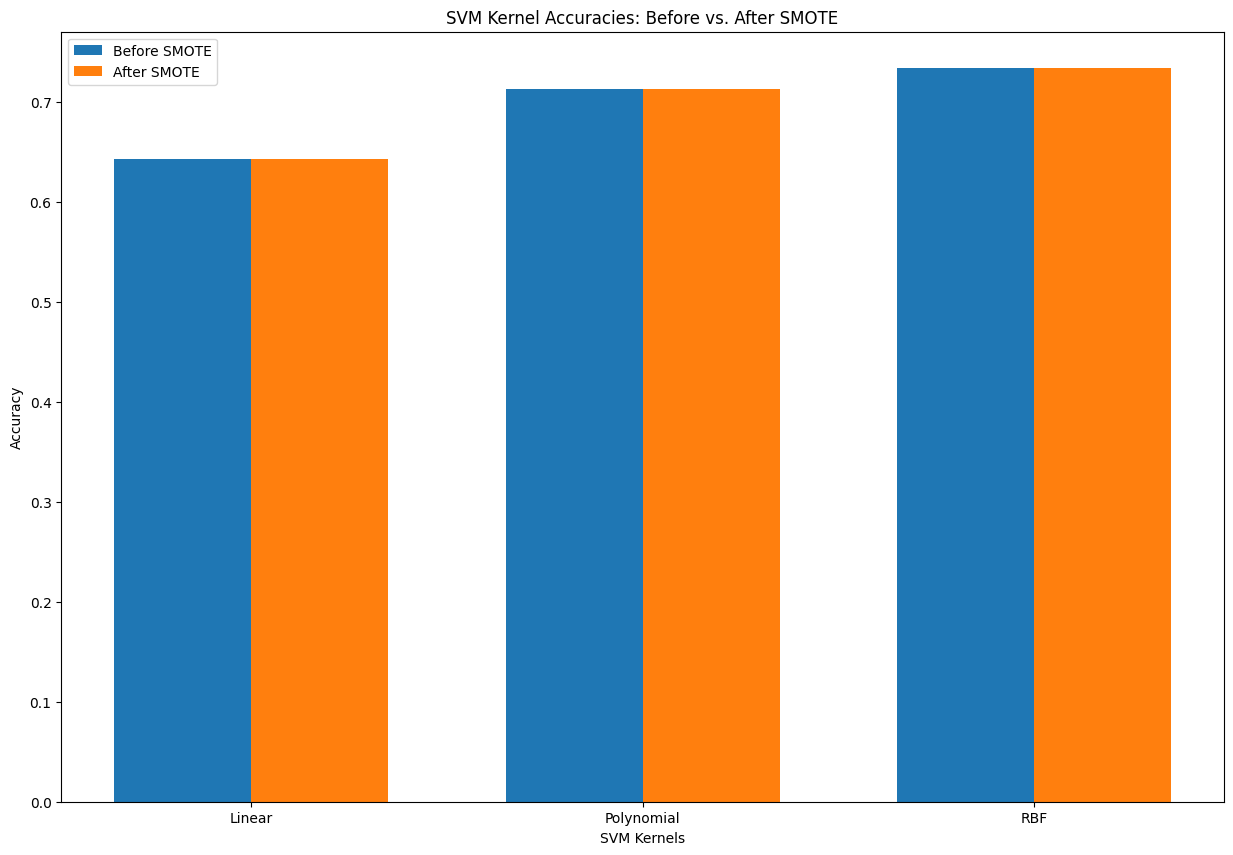

In [74]:
#comparion graph for SVM
import numpy as np
import matplotlib.pyplot as plt
kernels = ['Linear', 'Polynomial', 'RBF']
before_smote=[0.6434,0.7131,0.7336]
after_smote=[0.6434,0.7131,0.7336]
x_axis_labels = np.arange(len(kernels))
width = 0.35
plt.figure(figsize=(15,10))
plt.bar(x_axis_labels - width/2, before_smote, width, label='Before SMOTE')
plt.bar(x_axis_labels + width/2, after_smote, width, label='After SMOTE')
plt.xlabel("SVM Kernels")
plt.ylabel("Accuracy")
plt.title("SVM Kernel Accuracies: Before vs. After SMOTE")
plt.xticks(x_axis_labels, kernels)
plt.legend()
plt.show()

Average K-Fold Accuracy: 0.6281958737745696


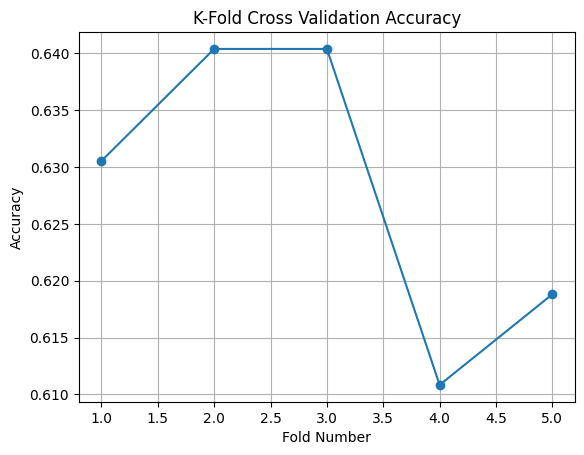

In [75]:
#comparion graph for K-Fold
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

kfold_scores = []

for train_index, test_index in kf.split(x):
    X_train, X_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train.values.ravel())

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    kfold_scores.append(acc)
print("Average K-Fold Accuracy:", np.mean(kfold_scores))
plt.figure()
plt.plot(range(1, 6), kfold_scores, marker='o')
plt.title("K-Fold Cross Validation Accuracy")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

Bootstrap Accuracy: [0.6390532544378699, 0.6400394477317555, 0.6183431952662722, 0.6351084812623274, 0.616370808678501]
Average Bootstrap Accuracy: 0.6297830374753453


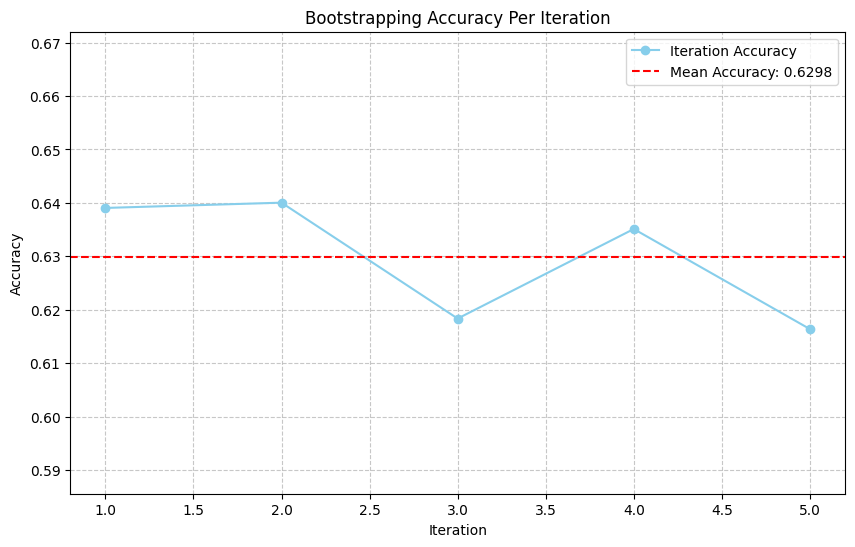

In [76]:
#COMPARISION GRAPH FOR BOOTSRAPING
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
bootstrap_scores = []
n_iterations = 5
for i in range(n_iterations):
    X_bs, y_bs = resample(x, y, replace=True, random_state=i)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_bs, y_bs.values.ravel())
    preds = model.predict(x)
    acc = accuracy_score(y, preds)
    bootstrap_scores.append(acc)
mean_bootstrap_accuracy = np.mean(bootstrap_scores);
print("Bootstrap Accuracy:", bootstrap_scores)
print("Average Bootstrap Accuracy:", mean_bootstrap_accuracy)

plt.figure(figsize=(10, 6))
plt.plot(range(1, n_iterations + 1), bootstrap_scores, marker='o', linestyle='-', color='skyblue', label='Iteration Accuracy')
plt.axhline(y=mean_bootstrap_accuracy, color='red', linestyle='--', label=f'Mean Accuracy: {mean_bootstrap_accuracy:.4f}')
plt.title('Bootstrapping Accuracy Per Iteration')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.ylim(min(bootstrap_scores) * 0.95, max(bootstrap_scores) * 1.05)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

KNN Accuracy: 0.7295081967213115
Best K: 1
Best Accuracy: 0.8440093098563043


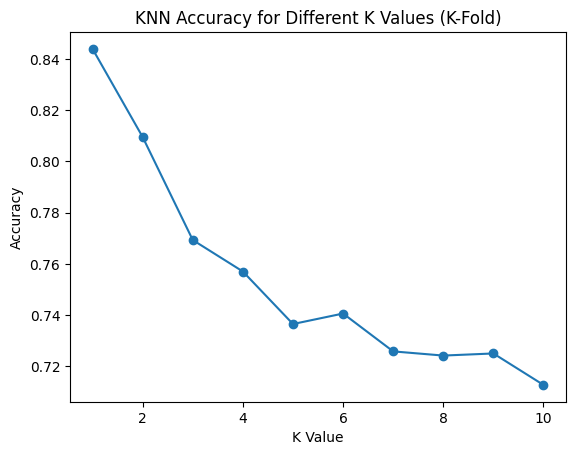

In [77]:
#KNN FOR DIFFERENT K VALUES
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import builtins
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=1)
x_u,y_u=sm.fit_resample(x,y)
X_train, X_test, y_train, y_test = train_test_split(x_u, y_u, test_size=0.2, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train.values.ravel())
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("KNN Accuracy:", acc)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
k_values = []
kfold_scores = []
for k in range(1, 11):
    scores = []
    for train_index, test_index in kf.split(x_u):
        X_train_kfold, X_test_kfold = x_u.iloc[train_index], x_u.iloc[test_index]
        y_train_kfold, y_test_kfold = y_u.iloc[train_index], y_u.iloc[test_index]
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train_kfold, y_train_kfold.values.ravel())
        preds = model.predict(X_test_kfold)
        scores.append(accuracy_score(y_test_kfold, preds))
    k_values.append(k)
    kfold_scores.append(builtins.sum(scores)/len(scores))
best_k = k_values[kfold_scores.index(max(kfold_scores))]
print("Best K:", best_k)
print("Best Accuracy:", max(kfold_scores))
plt.figure()
plt.plot(k_values, kfold_scores, marker='o')
plt.title("KNN Accuracy for Different K Values (K-Fold)")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.show()

In [78]:
#GRIDSEARCH
from sklearn import svm
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=1)
x_u,y_u=sm.fit_resample(x,y)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
param_dist={'C':[0.1,1,10],'gamma':[1,0.1,0.01],'kernel':['rbf','linear','poly']}
grid=GridSearchCV(SVC(),param_dist,cv=5)
grid.fit(x_train,y_train)
grid_pred=grid.predict(x_test)
grid_acc=accuracy_score(y_test,grid_pred)
print("GRID SEARCH ACCURANCY:",grid_acc)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

GRID SEARCH ACCURANCY: 0.6748768472906403


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [79]:
#RANDOM SEARCH
from sklearn import svm
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=1)
x_u,y_u=sm.fit_resample(x,y)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
param_dist={'C':[0.1,1,10],'gamma':[1,0.1,0.01],'kernel':['rbf','linear','poly']}
random=RandomizedSearchCV(SVC(),param_dist,cv=5,n_iter=5)
random.fit(x_train,y_train)
random_pred=random.predict(x_test)
random_acc=accuracy_score(y_test,random_pred)
print("RANDOM SEARCH ACCURANCY:",random_acc)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

RANDOM SEARCH ACCURANCY: 0.625615763546798


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Decision Tree Classifier
Accuracy: 0.8177339901477833
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.85      0.84        47
           1       0.86      0.78      0.82        80
           2       0.77      0.84      0.81        76

    accuracy                           0.82       203
   macro avg       0.82      0.82      0.82       203
weighted avg       0.82      0.82      0.82       203

Confusion Matrix:
 [[40  1  6]
 [ 5 62 13]
 [ 3  9 64]]


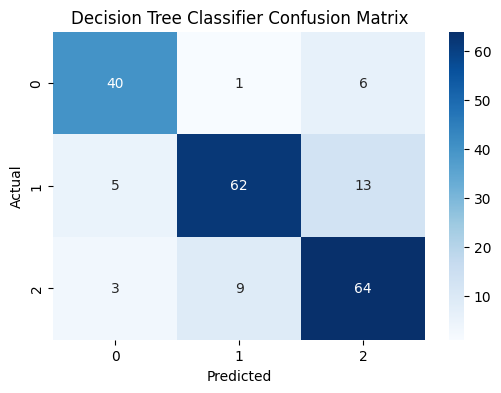

In [81]:
#DECISION TREE CLASSIFIER
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=1)
x_u,y_u=sm.fit_resample(x,y)
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(x_train, y_train)
y_pred_dt_classifier = dt_classifier.predict(x_test)
print("Decision Tree Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred_dt_classifier))
print("Classification Report:\n", classification_report(y_test, y_pred_dt_classifier))
cm_dt = confusion_matrix(y_test, y_pred_dt_classifier)
print("Confusion Matrix:\n", cm_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Classifier Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

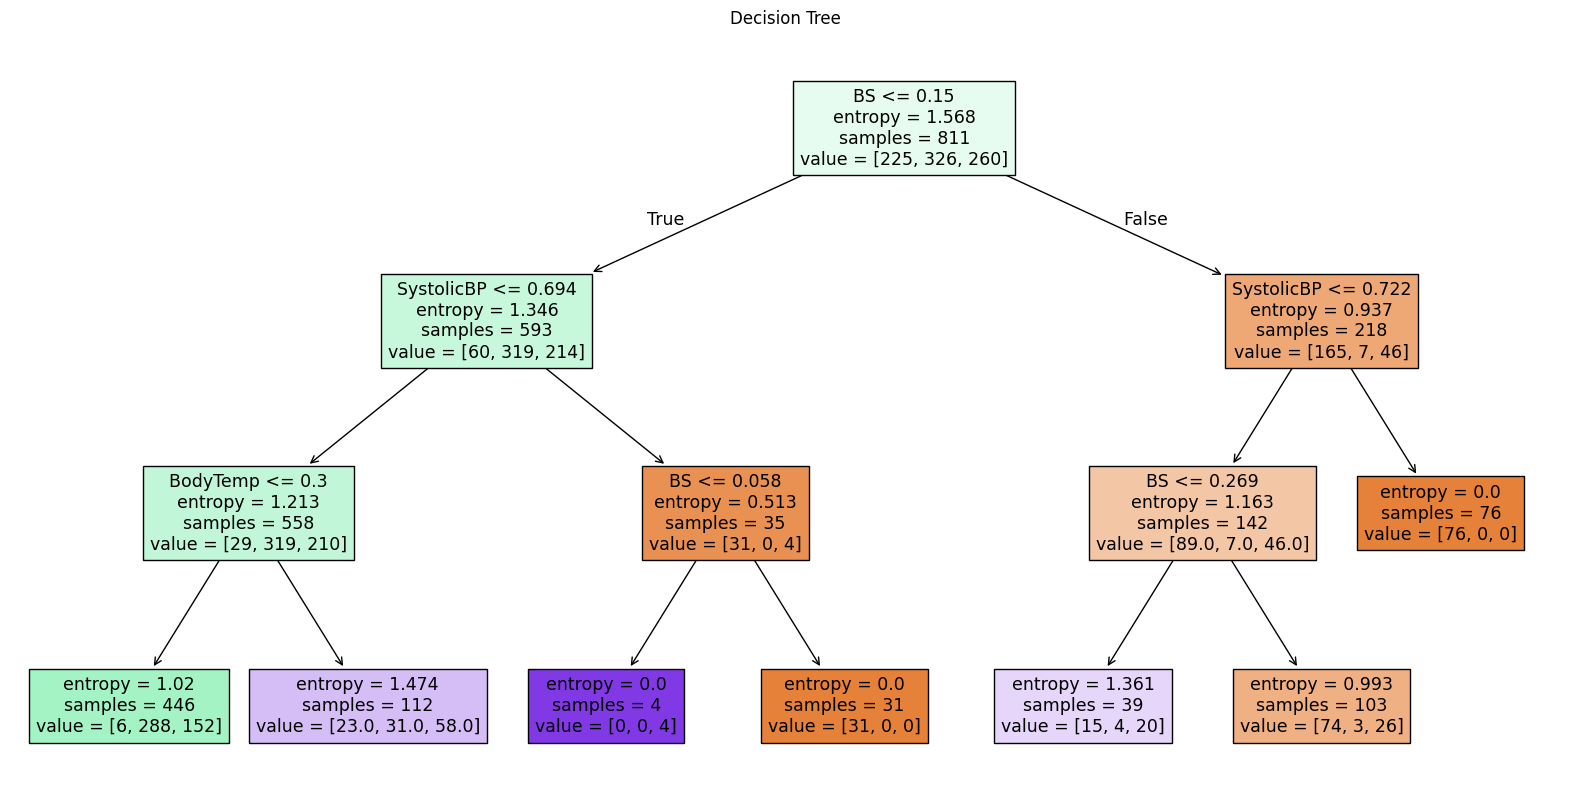

In [84]:
#DECISION TREE
from sklearn.tree import DecisionTreeClassifier, plot_tree
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=x_u.columns, filled=True)
plt.title("Decision Tree")
plt.show()

In [128]:
from sklearn.decomposition import PCA
n_components = 4
pca = PCA(n_components=n_components)
x_pca = pca.fit_transform(x_u)
print("Shape of data before PCA:", x_u.shape)
print("Shape of data after PCA:", x_pca.shape)

Shape of data before PCA: (1218, 6)
Shape of data after PCA: (1218, 4)


Accuracy (Before PCA): 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


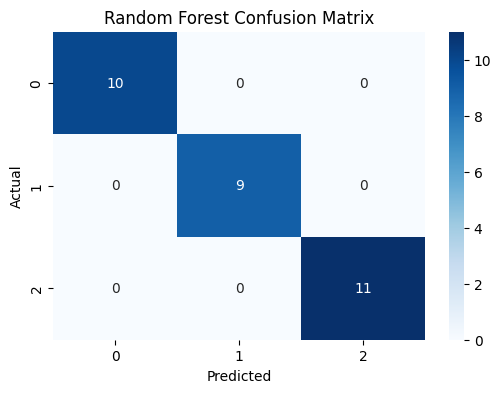

In [129]:
#random forest before PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
data = load_iris()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Accuracy (Before PCA):", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Accuracy (After PCA): 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


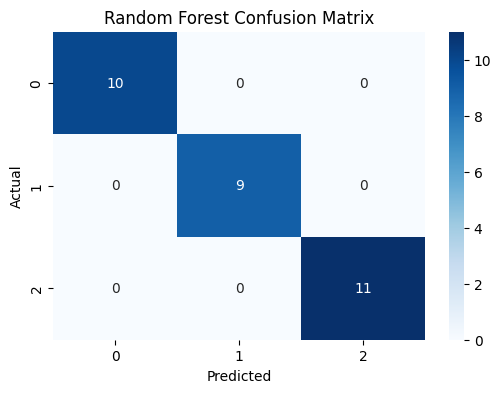

In [130]:
#random forest after PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pca.fit(X_train_pca, y_train)
y_pred_pca = rf_pca.predict(X_test_pca)
print("Accuracy (After PCA):", accuracy_score(y_test, y_pred_pca))
print("Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

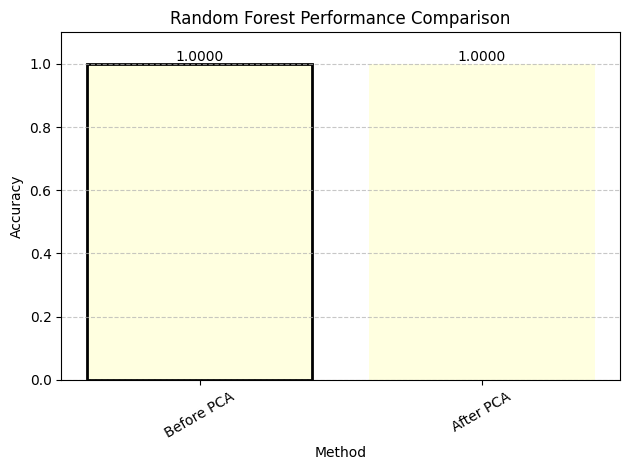

In [131]:
# Comparison plot for Random Forest before and after PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
methods = ['Before PCA', 'After PCA']
accuracies = [accuracy_score(y_test, y_pred),accuracy_score(y_test, y_pred_pca)]
plt.figure()
bars = plt.bar(methods, accuracies,color='lightyellow')
plt.xlabel('Method')
plt.ylabel('Accuracy')
plt.title('Random Forest Performance Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.4f}',
        ha='center',
        va='bottom'
    )
best_index = np.argmax(accuracies)
bars[best_index].set_edgecolor('black')
bars[best_index].set_linewidth(2)
plt.xticks(rotation=30)
plt.ylim(0, max(accuracies) + 0.1)
plt.tight_layout()
plt.show()

Accuracy (AdaBoost Before PCA): 0.9333333333333333
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.89      0.89      0.89         9
           2       0.91      0.91      0.91        11

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
 [[10  0  0]
 [ 0  8  1]
 [ 0  1 10]]


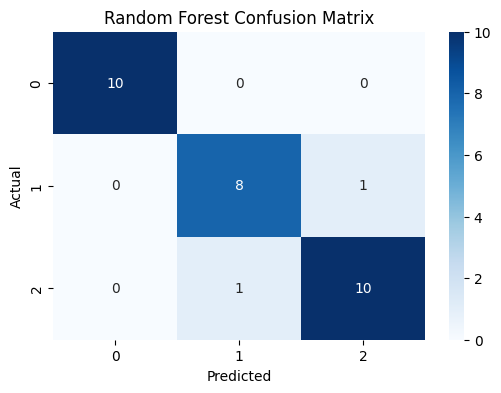

In [132]:
#ada boost before PCA
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (AdaBoost Before PCA):", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Accuracy (AdaBoost After PCA): 0.9666666666666667
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.89      0.89      0.89         9
           2       0.91      0.91      0.91        11

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
 [[10  0  0]
 [ 0  8  1]
 [ 0  1 10]]


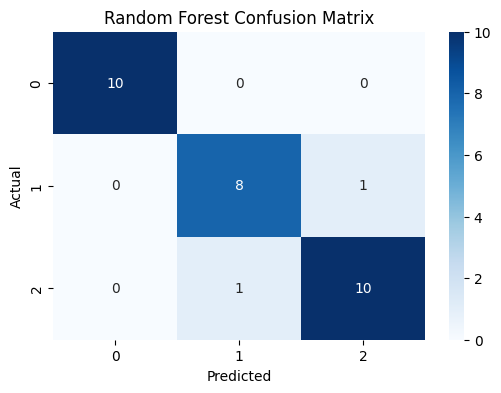

In [133]:
#ada boost after PCA
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)
ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
ada.fit(X_train_pca, y_train)
y_pred_pca = ada.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print("Accuracy (AdaBoost After PCA):", accuracy_pca)
print("Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

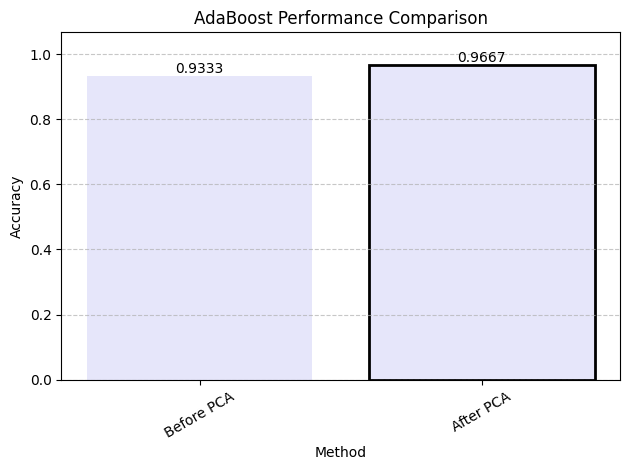

In [135]:
# Comparison plot for AdaBoost before and after PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
methods = ['Before PCA', 'After PCA']
accuracies = [accuracy, accuracy_pca]
plt.figure()
bars = plt.bar(methods, accuracies,color='lavender')
plt.xlabel('Method')
plt.ylabel('Accuracy')
plt.title('AdaBoost Performance Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.4f}',
        ha='center',
        va='bottom'
    )
best_index = np.argmax(accuracies)
bars[best_index].set_edgecolor('black')
bars[best_index].set_linewidth(2)
plt.xticks(rotation=30)
plt.ylim(0, max(accuracies) + 0.1)
plt.tight_layout()
plt.show()

Accuracy (G Boost Before PCA): 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


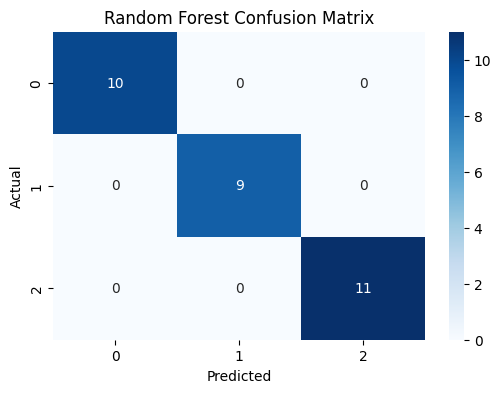

In [136]:
#G Boost before PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (G Boost Before PCA):", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Accuracy (G Boost After PCA): 0.9666666666666667
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


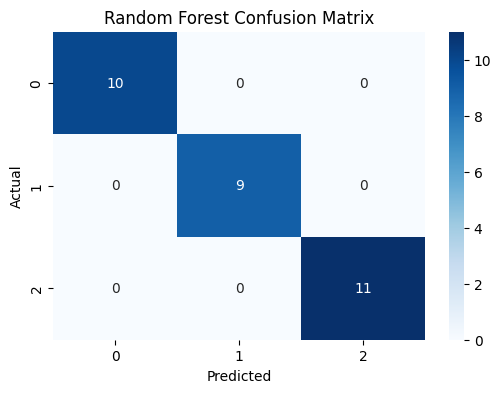

In [137]:
#G Boost after PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
gb.fit(X_train_pca, y_train)
y_pred_pca = gb.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print("Accuracy (G Boost After PCA):", accuracy_pca)
print("Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

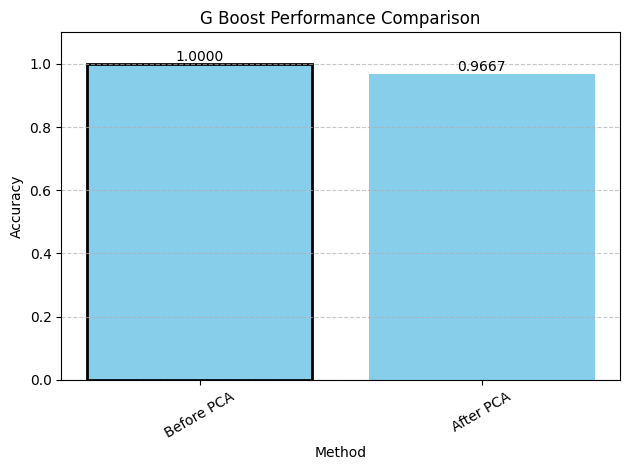

In [138]:
#comparision plot for G Boost before and after PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
methods = ['Before PCA', 'After PCA']
accuracies = [accuracy, accuracy_pca]
plt.figure()
bars = plt.bar(methods, accuracies,color='skyblue')
plt.xlabel('Method')
plt.ylabel('Accuracy')
plt.title('G Boost Performance Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.4f}',
        ha='center',
        va='bottom'
    )
best_index = np.argmax(accuracies)
bars[best_index].set_edgecolor('black')
bars[best_index].set_linewidth(2)
plt.xticks(rotation=30)
plt.ylim(0, max(accuracies) + 0.1)
plt.tight_layout()
plt.show()

Accuracy (XGBoost Before PCA): 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


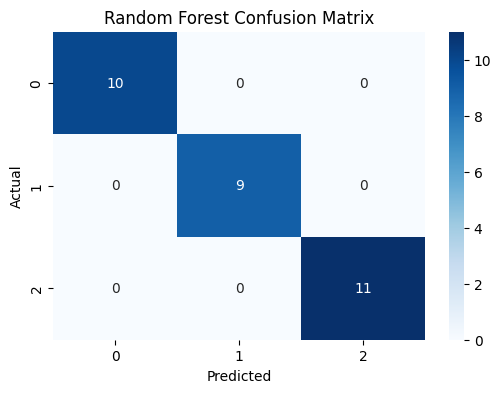

In [139]:
#XG boost before PCA
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (XGBoost Before PCA):", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Accuracy (XGBoost After PCA): 0.9666666666666667
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


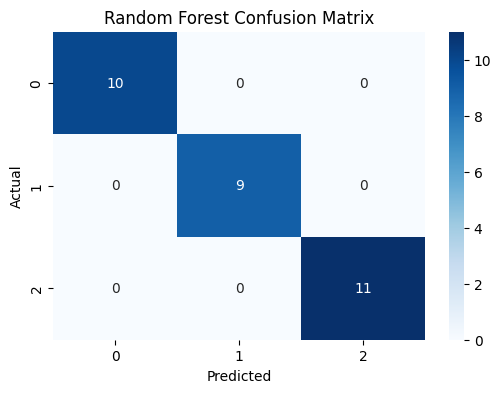

In [140]:
#XG Boost after PCA
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)
xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train_pca, y_train)
y_pred_pca = xgb.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print("Accuracy (XGBoost After PCA):", accuracy_pca)
print("Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

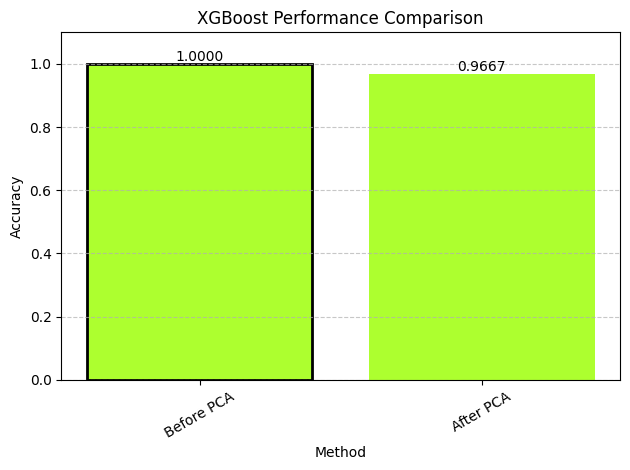

In [141]:
#comparision plot for XG Boost before and after PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
methods = ['Before PCA', 'After PCA']
accuracies = [accuracy, accuracy_pca]
plt.figure()
bars = plt.bar(methods, accuracies,color='greenyellow')
plt.xlabel('Method')
plt.ylabel('Accuracy')
plt.title('XGBoost Performance Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.4f}',
        ha='center',
        va='bottom'
    )
best_index = np.argmax(accuracies)
bars[best_index].set_edgecolor('black')
bars[best_index].set_linewidth(2)
plt.xticks(rotation=30)
plt.ylim(0, max(accuracies) + 0.1)
plt.tight_layout()
plt.show()

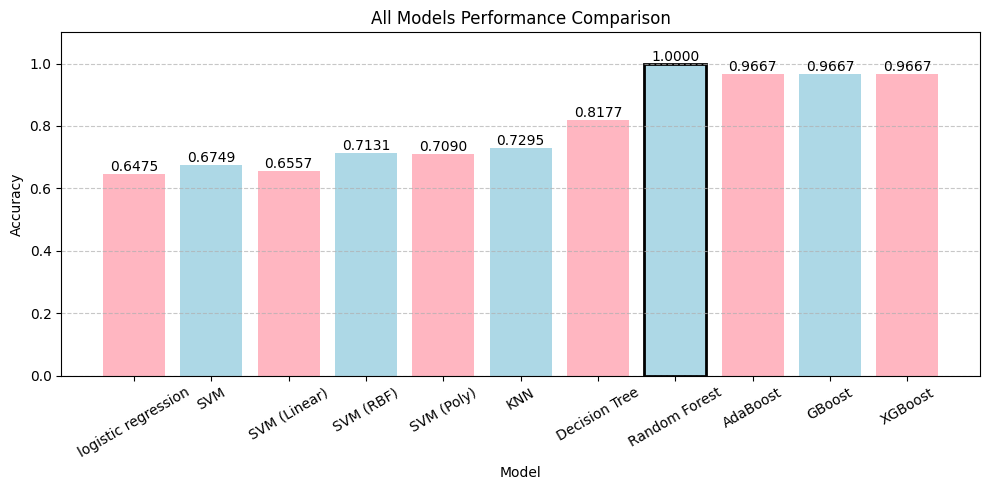

In [142]:
# All models comparison plot
import matplotlib.pyplot as plt
import numpy as np
lr_acc=0.6475409836065574
svm_acc = 0.6748768472906403
svm_linear_acc = 0.6557377049180327
svm_rbf_acc = 0.7131147540983607
svm_poly_acc = 0.7090163934426229
knn_acc = 0.7295081967213115
DT_accuracy = 0.8177339901477833
rf_acc = 1.0
ada_acc = 0.9666666666666667
gb_acc = 0.9666666666666667
xgb_acc =  0.9666666666666667
methods = ['logistic regression','SVM','SVM (Linear)', 'SVM (RBF)', 'SVM (Poly)', 'KNN', 'Decision Tree', 'Random Forest', 'AdaBoost','GBoost','XGBoost']
accuracies = [lr_acc,svm_acc,svm_linear_acc, svm_rbf_acc, svm_poly_acc, knn_acc, DT_accuracy, rf_acc, ada_acc,gb_acc,xgb_acc]
plt.figure(figsize=(10,5))
colour=['lightpink','lightblue','lightpink','lightblue','lightpink','lightblue','lightpink','lightblue','lightpink','lightblue']
bars = plt.bar(methods, accuracies, color=colour)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('All Models Performance Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.4f}',
        ha='center',
        va='bottom'
    )
best_index = np.argmax(accuracies)
bars[best_index].set_edgecolor('black')
bars[best_index].set_linewidth(2)
plt.xticks(rotation=30)
plt.ylim(0, max(accuracies) + 0.1)
plt.tight_layout()
plt.show()